In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import optuna
from math import sqrt
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

c:\Users\arau7\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Загрузка данных

In [2]:
data = fetch_california_housing(as_frame=True)
data.frame

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### Выделение целевого признака и предикторов

In [3]:
y = data.target
X = data.data

In [4]:
print("матрица объект-признак:")
X

матрица объект-признак:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
print("список целевых значений:")
y

список целевых значений:


0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

# 1. Разбиение на обучающую и тестовую выборки

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
print(f"\nРазмеры выборок:")
print(f"Обучающая: {X_train.shape}, {y_train.shape}")
print(f"Тестовая: {X_test.shape}, {y_test.shape}")


Размеры выборок:
Обучающая: (16512, 8), (16512,)
Тестовая: (4128, 8), (4128,)


# 2. Модель и метрики

In [8]:
model = RandomForestRegressor().fit(X_train, y_train)
y_pred = model.predict(X_test)

In [9]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')

MAE: 0.3191672322189924
MSE: 0.23860364665808312
RMSE: 0.48847072241648537
MAPE: 0.17956556078925578
R^2: 0.8230631492446652


# 3. Подбор гиперпараметров

In [10]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_squared_error')
    
    return scores.mean()

In [11]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

[I 2025-10-07 19:37:18,762] A new study created in memory with name: no-name-bbc845be-0080-4d4a-8970-3590b8af1229
[I 2025-10-07 19:37:20,613] Trial 0 finished with value: -0.43039309850416857 and parameters: {'n_estimators': 286, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.43039309850416857.
[I 2025-10-07 19:37:21,569] Trial 1 finished with value: -0.27566340570401243 and parameters: {'n_estimators': 73, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: -0.27566340570401243.
[I 2025-10-07 19:37:23,989] Trial 2 finished with value: -0.2806521189834991 and parameters: {'n_estimators': 170, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: -0.27566340570401243.
[I 2025-10-07 19:37:26,244] Trial 3 finished with value: -0.26605255812753054 and parameters: {'n_estimators': 135, 'max_dep

In [12]:
print(f"\nЛучшие гиперпараметры: {study.best_params}")
print(f"Лучшее значение метрики: {study.best_value}")


Лучшие гиперпараметры: {'n_estimators': 85, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}
Лучшее значение метрики: -0.2556231953334779


### Обучение с лучшими параметрами

In [13]:
best_params = study.best_params
best_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=17, max_features='log2', min_samples_split=8,
                      n_estimators=85, n_jobs=-1, random_state=42)

# 4. Получите предсказание на обученной модели.

In [14]:
y_pred = best_model.predict(X_test)

### Оценка качества модели

In [15]:
print("="*50)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")
print("="*50)

metrics = {
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': sqrt(mean_squared_error(y_test, y_pred)),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred),
    'R²': r2_score(y_test, y_pred)
}

for metric_name, value in metrics.items():
    print(f'{metric_name}: {value:.4f}')

ОЦЕНКА КАЧЕСТВА МОДЕЛИ
MAE: 0.3218
MSE: 0.2324
RMSE: 0.4820
MAPE: 0.1847
R²: 0.8277


# 5. Визуализация

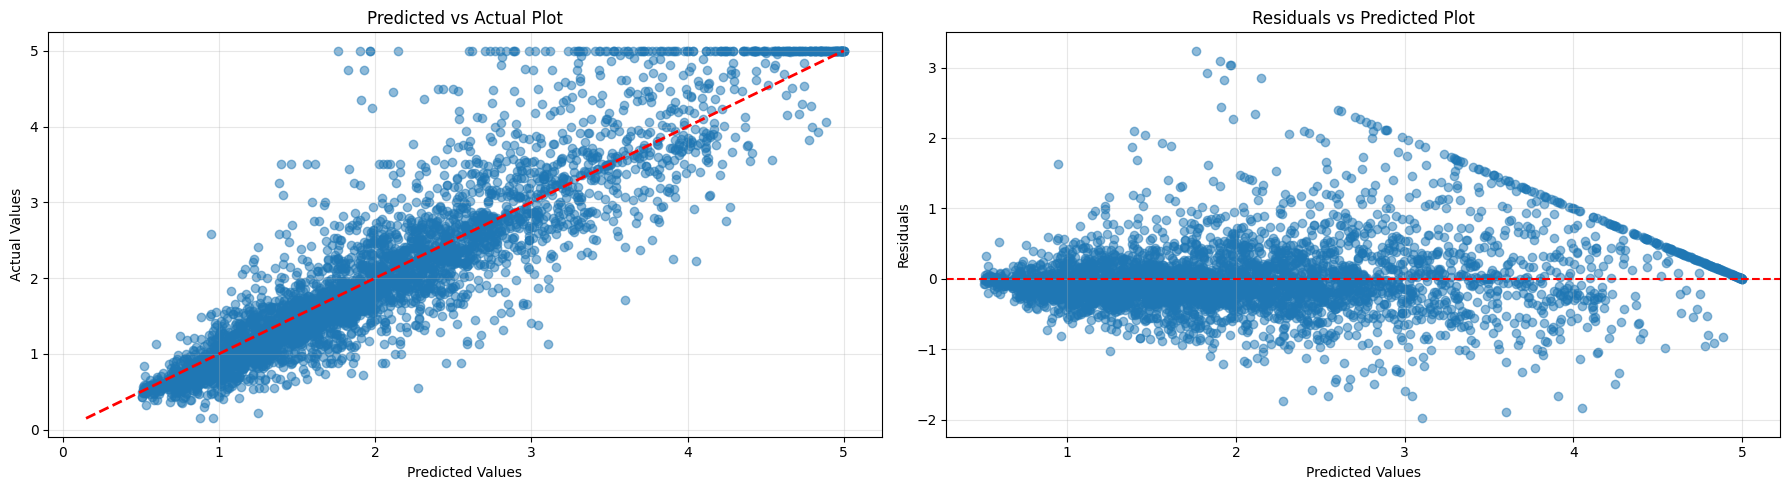

СТАТИСТИКА ОСТАТКОВ:
Среднее остатков: -0.0023
Стандартное отклонение остатков: 0.4821
Минимальный остаток: -1.9809
Максимальный остаток: 3.2388


In [18]:
def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    axes[0].scatter(y_pred, y_true, alpha=0.5)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Actual Values')
    axes[0].set_title('Predicted vs Actual Plot')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(y_pred, residuals, alpha=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residuals vs Predicted Plot')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("СТАТИСТИКА ОСТАТКОВ:")
    print(f"Среднее остатков: {residuals.mean():.4f}")
    print(f"Стандартное отклонение остатков: {residuals.std():.4f}")
    print(f"Минимальный остаток: {residuals.min():.4f}")
    print(f"Максимальный остаток: {residuals.max():.4f}")

plot_residuals(y_test, y_pred)